<a href="https://colab.research.google.com/github/amit-chaubey/base-ml-model/blob/main/EMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#We are going to import few libraries namely for:
###1. Computation
###2. Exploration
###3. Implementation
###4. Visualisation

In [ ]:
!pip install keras-tuner

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 1.1 MB/s eta 0:00:00


In [ ]:
import torch
torch.manual_seed(25)
import torchvision
import torch.nn as nn

# For visualising the data
import matplotlib.pyplot as plt
import seaborn as sns

# For Computational Purpose
import numpy as np

# To time stamp the progress of the algorithms
import time

# To visualise the DataFrame
import pandas as pd

# For model
import tensorflow as tf
import torch.nn.functional as F
from torch import nn, optim, cuda
from torch.optim.lr_scheduler import StepLR, ExponentialLR


#To plot the different matrics helping visualise the result
from sklearn.metrics import confusion_matrix, classification_report

import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader, TensorDataset, random_split

from IPython.display import display, HTML

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.regularizers import l1, l2
from keras_tuner import RandomSearch


# Just in case we need to log the time we can use logging library, we can additionally also consider importing time library

In [ ]:
import torch.optim as optim
import time
import logging


# For large file handling and highly complex alogrithm we require additional processing support, therefore we are looking for cuda if available

In [ ]:
#for computational purpose we look for a cuda device if available
device = "cuda" if cuda.is_available() else "cpu"

#The data is stored in our google drive and therefore we neeed to mount the drive, here is how we can do

In [ ]:
# To mount the drive so that we get access to our dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Let's load the dataset from our google drive along with loading mapping file.

In [ ]:
# Load the dataset
train_data = pd.read_csv('/content/drive/MyDrive/datasets/emnist-balanced-train.csv', header=None)
test_data = pd.read_csv('/content/drive/MyDrive/datasets/emnist-balanced-test.csv', header=None)

# Load the mapping and converting dataframe to a series by selecting second column which holds ASCII values
mapping = pd.read_csv('/content/drive/MyDrive/datasets/emnist-balanced-mapping.txt', delimiter=' ', index_col=0, header=None)[1].squeeze()


In [ ]:
batch_size= 64

# Dataloader for entire dataset
train_dl = torch.utils.data.DataLoader(train_data, shuffle=True)

# Calculate the size of the training and validation sets
trainSplit = int(0.8 * len(train_dl))  # 80% is used for training
valSplit = len(train_dl) - trainSplit  # 20% is used for validation
X_train, X_val = torch.utils.data.random_split(train_data, [trainSplit, valSplit])

# Dataloader
train_dl = DataLoader(X_train, batch_size=batch_size, shuffle=True)
validation_dl = DataLoader(X_val, batch_size=batch_size, shuffle=False) # segregate the validation dataset from the training dataset
test_dl = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# # # Assuming `mapping` is a dict that maps label indices to characters
# classes = [chr(mapping[i]) for i in range(47)]
# print(f'Classes: {classes}')


<!-- Detailed Explanation for the code piece above: -->

#The code in the cell below performs the following tasks:

###1. It defines a transformation pipeline using `transforms.Compose` to preprocess images before feeding them into the model. This includes tasks like converting tensors to PIL images, rotating the images 90 degrees and anti-clockwise, flipping the images horizontally, and converting PIL Images back to tensors.
###2. It defines a function `prepare_data` to extract target labels and reshape image data for PyTorch training.
###3. It defines another function `apply_transform` to apply the specified transformation to the input images.
###4. Prepares training and testing datasets by applying the transformation to the images.
###5. Splits the training data into training and validation sets of 80% and 20%.
###6. Creates `TensorDataset` instances for both training and test datasets.
###7. Splits the training dataset to create a separate validation dataset using `random_split`.
##8. Creates `DataLoader` instances for training, validation, and testing, specifying batch size and shuffling where necessary.

In [ ]:

# Define a transformation pipeline
# Assuming the images are in the CSV as flat rows and need to be reshaped into 28x28 images
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Lambda(lambda img: transforms.functional.rotate(img, -90)),
    transforms.Lambda(lambda img: transforms.functional.hflip(img)),
    transforms.ToTensor()
])

# Prepare the data and targets for PyTorch
def prepare_data(dataframe):
    """
    Converts DataFrame to normalized tensors of images and target labels, formatting images as 1x28x28.
    Returns a tuple of tensors (images, targets).
    """
    targets = torch.tensor(dataframe.iloc[:, 0].values).long()
    # Reshape the images to 1x28x28 and normalize
    images = torch.tensor(dataframe.iloc[:, 1:].values).float().view(-1, 1, 28, 28) / 255.0
    return images, targets

# Apply transformation
def apply_transform(images, transform):
    """
    Applies a specified transform to a batch of images and returns the transformed images as a stacked tensor.
    """
    transformed_images = torch.stack([transform(img) for img in images])
    return transformed_images

# Get prepared data
train_images, train_targets = prepare_data(train_data)
test_images, test_targets = prepare_data(test_data)

# Apply transformations
train_images = apply_transform(train_images, transform)
test_images = apply_transform(test_images, transform)

# Split the training data into training and validation sets
train_size = int(0.8 * len(train_images))  # 80% for training
val_size = len(train_images) - train_size  # 20% for validation

# Create TensorDataset
train_dataset = TensorDataset(train_images, train_targets)
test_dataset = TensorDataset(test_images, test_targets)

# Split train_dataset to create validation dataset
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

# DataLoader instances
batch_size = 64
train_dl = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
validation_dl = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
test_dl = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)



In [ ]:
def find_unique_shapes(dataloader):
    """
    Collect unique image shapes from a given DataLoader, aiding in dataset analysis.
    Returns a set of unique image shapes (tuple format) found in the dataloader.
    """

    # Find unique shapes in training, validation, and test datasets and print them along with class labels.
    unique_shapes = set()
    for images, _ in dataloader:
        for image in images:
            unique_shapes.add(tuple(image.shape))
    return unique_shapes

# Find unique shapes in the datasets
train_shapes = find_unique_shapes(train_dl)
validation_shapes = find_unique_shapes(validation_dl)
test_shapes = find_unique_shapes(test_dl)

print("Unique shapes in training data:", train_shapes)
print("Unique shapes in validation data:", validation_shapes)
print("Unique shapes in test data:", test_shapes)


classes = [chr(mapping[i]) for i in range(47)]
print(f'Classes: {classes}')


Unique shapes in training data: {(1, 28, 28)}
Unique shapes in validation data: {(1, 28, 28)}
Unique shapes in test data: {(1, 28, 28)}
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']


<!-- Detailed Explanation -->

#The code below defines three functions:
###1. `label_to_ascii`: Converts a numerical label index to its corresponding ASCII character using a provided mapping.
###2. `prepare_image`: Reshapes, rotates, and flips the image pixels to ensure proper orientation for visualization.
###3. `visualize_images`: Visualizes a 4x4 grid of images from the dataset, optionally displaying the truth labels if a mapping is provided.These functions are then utilized to visualize both labeled and unlabeled data. For labeled data, the ground truth labels are displayed along with the images, while for unlabeled data, only the images are visualized.

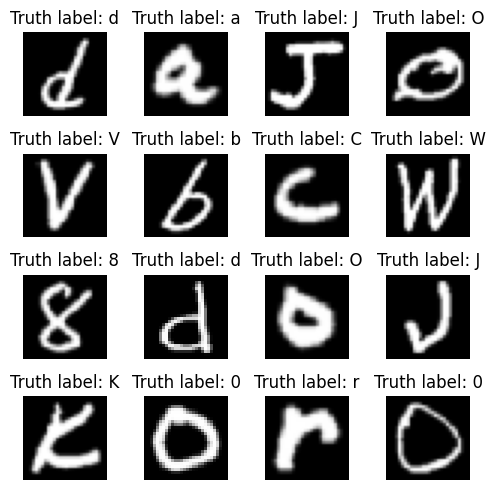

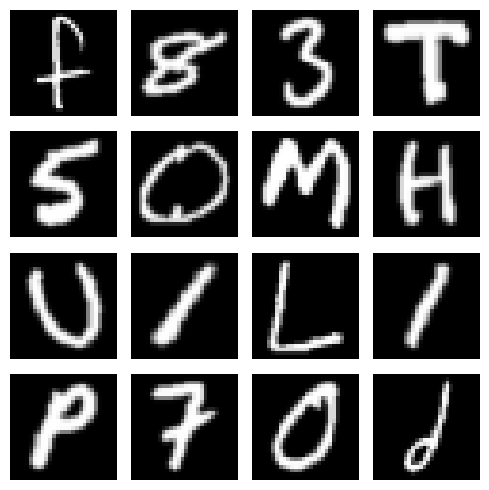

In [ ]:
def label_to_ascii(label_idx, mapping):
    """Converts a numerical label index to its corresponding ASCII character using a mapping."""
    return chr(mapping[label_idx])

def prepare_image(image_pixels):
    """Reshapes, rotates, and flips the image pixels for proper orientation."""
    # Check if the first column should be excluded
    if len(image_pixels) == 785:  # If there are 785 elements, exclude the first one
        image_pixels = image_pixels[1:]
    image = image_pixels.reshape(28, 28).astype('uint8')
    image = np.rot90(image, 3)
    image = np.fliplr(image)
    return image


def visualize_images(data, mapping=None):
    """Visualizes a 4x4 grid of images from the dataset."""
    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(5, 5))
    for ax in axes.flatten():
        random_idx = np.random.randint(len(data))
        # Explicitly check if mapping is not None
        if mapping is not None:
            # Labeled data: Exclude the first element for the label
            image_pixels = data.iloc[random_idx, 1:].values
            label_idx = data.iloc[random_idx, 0]
            ascii_label = label_to_ascii(label_idx, mapping)
            title = f'Truth label: {ascii_label}'
        else:
            # Unlabeled data: Use all elements as they are
            image_pixels = data.iloc[random_idx].values
            title = None

        image = prepare_image(image_pixels)
        ax.imshow(image, cmap='gray')
        if title is not None:  # Here we also check explicitly for None
            ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Use the functions to visualize labeled and unlabeled data
display(HTML(f"<div style='font-size:30px;'>-----Visualising the labelled data------</div>"))
visualize_images(train_data, mapping=mapping)

display(HTML(f"<div style='font-size:30px;'>-----Visualising the unlabelled data-----</div>"))
visualize_images(test_data)

In [ ]:
# input_shape = 784
# num_classes = 47

# def tunable_model(hp):
#     model = Sequential()
#     model.add(Dense(hp.Int('units', min_value=32, max_value=512, step=32), input_shape=(input_shape,)))
#     model.add(Activation(hp.Choice('activation', values=['relu', 'elu', 'leaky_relu'])))

#     # Optional Batch Normalization
#     if hp.Boolean('batch_normalization'):
#         model.add(BatchNormalization())

#     # Optional Dropout
#     if hp.Boolean('dropout'):
#         model.add(Dropout(hp.Float('dropout_rate', min_value=0.0, max_value=0.5, step=0.1)))

#     # Adding regularization
#     if hp.Choice('regularization', values=['none', 'l1', 'l2']) == 'l1':
#         model.add(Dense(num_classes, activation='softmax', kernel_regularizer=l1(0.01)))
#     elif hp.Choice('regularization', values=['none', 'l1', 'l2']) == 'l2':
#         model.add(Dense(num_classes, activation='softmax', kernel_regularizer=l2(0.01)))
#     else:
#         model.add(Dense(num_classes, activation='softmax'))

#     # Optimizer selection
#     optimizer_choice = hp.Choice('optimizer', values=['adam', 'sgd', 'rmsprop'])
#     if optimizer_choice == 'adam':
#         optimizer = Adam(learning_rate=hp.Float('adam_lr', min_value=1e-4, max_value=1e-2, sampling='LOG'))
#     elif optimizer_choice == 'sgd':
#         optimizer = SGD(learning_rate=hp.Float('sgd_lr', min_value=1e-4, max_value=1e-2, sampling='LOG'))
#     else:
#         optimizer = RMSprop(learning_rate=hp.Float('rmsprop_lr', min_value=1e-4, max_value=1e-2, sampling='LOG'))

#     model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
#     return model


# tuner = RandomSearch(
#     build_tunable_model,
#     objective='val_accuracy',
#     max_trials=20,  # Increase trials for more thorough search
#     executions_per_trial=2,
#     directory='my_dir',
#     project_name='hyperparam_tuning'
# )


# tuner.search(x_train, y_train, epochs=10, validation_data=(x_test, y_test))
# best_model = tuner.get_best_models(num_models=1)[0]


# loss, accuracy = best_model.evaluate(x_test, y_test)
# print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')

<!-- Detailed Explanation -->

###The function `plot_training_metrics` is used to visualize the training and validation metrics (loss and accuracy) over epochs.

###The function plots the loss and accuracy curves in a 1x2 subplot grid, with loss on the left and accuracy on the right. Each subplot includes a legend to distinguish between training and validation metrics. Both these graphs are based on the training and validation data.

In [ ]:
import matplotlib.pyplot as plt

def plot_training_metrics(train_losses, val_losses, train_acc, val_acc):
    """
    Plot training and validation loss and accuracy over epochs.

    This function creates two side-by-side plots: one for loss and one for accuracy,
    comparing the training and validation metrics across epochs. This visualization helps
    in assessing how well the model is learning and generalizing over time.

    Parameters:
        train_losses (list of float): A list containing the loss values recorded during training.
        val_losses (list of float): A list containing the loss values recorded during validation.
        train_acc (list of float): A list containing the accuracy values recorded during training.
        val_acc (list of float): A list containing the accuracy values recorded during validation.

    Example:
        >>> plot_training_metrics(train_losses, val_losses, train_acc, val_acc)

    The function does not return any values; it outputs the plots directly using matplotlib.
    """
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Loss over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Accuracy over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

<!-- Detailed Explanation -->

##The `MLP` class defines a Multi-Layer Perceptron (MLP) neural network model using PyTorch.
## Constructor (`__init__` method):
###- Initializes the model architecture with specified input, hidden, and output sizes.
###- Allows for optional dropout and batch normalization for regularization.
## Forward Pass (`forward` method):
###- Performs the forward pass of the model.
###- Flattens the input images and passes them through the sequential hidden layers.
###- Returns the output logits.
##This architecture is designed for image classification tasks, with customizable hidden layer sizes and regularization techniques.

In [ ]:

# MLP (Multi Layer Perceptron)

class MLP(nn.Module):
    """
    A Multi Layer Perceptron (MLP) for image classification.

    The MLP architecture includes a sequence of hidden layers with ReLU activation functions,
    optional dropout, and batch normalization to improve generalization and training speed.
    This model is well-suited for flat input data, such as vectors extracted from images.

    Parameters:
        input_size (int): The size of the input features.
        hidden_size (int): The size of the hidden layers.
        output_size (int): The number of output classes.
        dropout (float, optional): The dropout rate for regularization. Defaults to 0.2.
        batchNorm (bool, optional): Whether to apply batch normalization. Defaults to True.

    Example:
        >>> input_size = 28 * 28  # for flattened 28x28 input images
        >>> hidden_size = 512
        >>> output_size = 47  #  number of classes in EMNIST
        >>> model = MLP(input_size, hidden_size, output_size).to(device)
        >>> print(model)
    """
    def __init__(self, input_size, hidden_size, output_size, dropout=0.2, batchNorm= True):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten() #  Flatten the output and save it to the flatten variable of the current instance
        self.hidden_layers = nn.Sequential( #  Create sequential hidden layers for MLP
            nn.Linear(input_size, hidden_size), #  Set first linear Layer
            nn.ReLU(), #  Set activation as relu
            nn.Dropout(p=dropout), #  Set dropout
            nn.BatchNorm1d(hidden_size) if batchNorm else nn.Identity(), #  Check is batchNorm is enabled
            nn.Linear(hidden_size, hidden_size), #  Set second hidden layer
            nn.ReLU(), #  Set activation to relu
            nn.Dropout(p=dropout), #  Set dropout
            nn.BatchNorm1d(hidden_size) if batchNorm else nn.Identity(), #  Check is batchNorm is enabled
            nn.Linear(hidden_size, hidden_size), #  Set third hidden layer
            nn.ReLU(), #  Set activation function
            nn.Dropout(p=dropout), #  Set dropout
            nn.BatchNorm1d(hidden_size) if batchNorm else nn.Identity(), #  Set batch normalisation
            nn.Linear(hidden_size, output_size) #  Set the output layer
        )


    def forward(self, x):
        """
        Define the forward pass of the MLP model.

        Parameters:
            x (torch.Tensor): The input data tensor.

        Returns:
            torch.Tensor: The logits tensor from the output layer of the MLP.
        """
        x = self.flatten(x)
        hidden = self.hidden_layers(x) # get the hidden layers output
        logits = hidden
        return logits # return the output

input_size = 28 * 28  # input images are of size 28x28
hidden_size = 512
output_size = len([chr(mapping[i]) for i in range(47)])  # Number of classes in the dataset

mlp = MLP(input_size, hidden_size, output_size).to(device)
print(mlp)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden_layers): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): Linear(in_features=512, out_features=512, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.2, inplace=False)
    (11): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): Linear(in_features=512, out_features=47, bias=True)
  )
)


<!-- Detailed Explanation -->

##The code below trains an MLP model using the provided training and validation data loaders.

###1. **Loss Function**: Cross-entropy loss is used for training the classification model.
###2. **Optimizer**: Adam optimizer is used to optimize the model parameters.
###3. **Learning Rate Scheduler**: StepLR scheduler is used to adjust the learning rate during training.
###4. **Training Loop**: The model is trained over a specified number of epochs. During each epoch, the training and validation data are used to compute losses and accuracies. The model parameters are updated using backpropagation.
###5. **Training Metrics**: Training losses and accuracies are computed and stored for each epoch.
###6. **Validation Metrics**: Validation losses and accuracies are computed and stored for each epoch.
###7. **Learning Rate Scheduling**: The learning rate is adjusted based on the specified schedule.
###8. **Training Time**: The total training time is calculated and printed after training completes.
###9. **Visualization**: After training, the training and validation metrics are visualized using the `plot_training_metrics` function.
# The Best MLP Model

Epoch [1/10], Training Loss: 1.0792, Training Accuracy: 0.6670, Validation Loss: 0.6838, Validation Accuracy: 0.7822
Epoch [2/10], Training Loss: 0.7417, Training Accuracy: 0.7564, Validation Loss: 0.5550, Validation Accuracy: 0.8140
Epoch [3/10], Training Loss: 0.6643, Training Accuracy: 0.7788, Validation Loss: 0.5156, Validation Accuracy: 0.8270
Epoch [4/10], Training Loss: 0.6156, Training Accuracy: 0.7918, Validation Loss: 0.4932, Validation Accuracy: 0.8320
Epoch [5/10], Training Loss: 0.5853, Training Accuracy: 0.7996, Validation Loss: 0.4979, Validation Accuracy: 0.8356
Epoch [6/10], Training Loss: 0.4711, Training Accuracy: 0.8347, Validation Loss: 0.4492, Validation Accuracy: 0.8597
Epoch [7/10], Training Loss: 0.4390, Training Accuracy: 0.8450, Validation Loss: 0.4565, Validation Accuracy: 0.8607
Epoch [8/10], Training Loss: 0.4220, Training Accuracy: 0.8502, Validation Loss: 0.4561, Validation Accuracy: 0.8618
Epoch [9/10], Training Loss: 0.4104, Training Accuracy: 0.8535, 

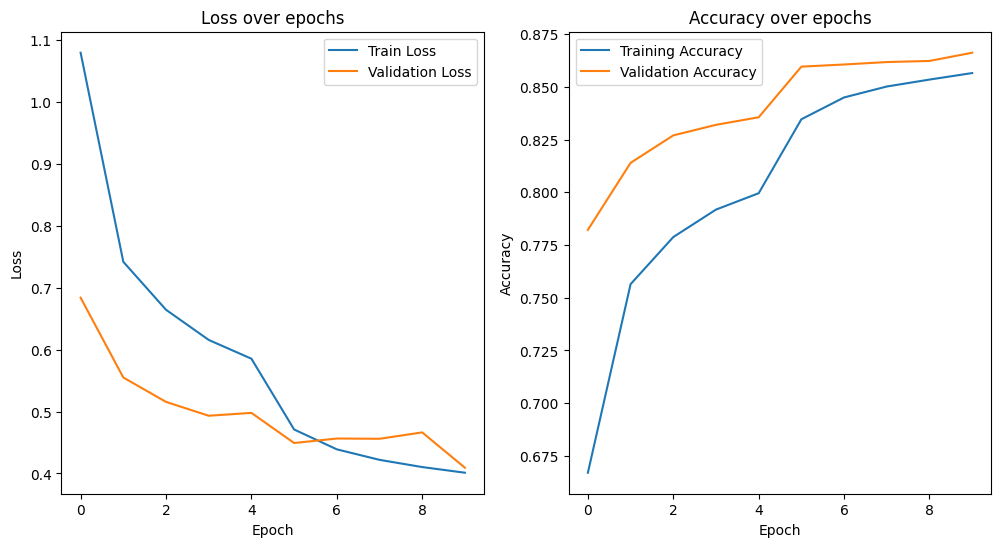

In [ ]:
# Train MLP model
# Loss function
criterion = nn.CrossEntropyLoss()
# Optimizer
optimizer = optim.Adam(mlp.parameters(), lr=0.005)
# Learning rate scheduler
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
mlp.to(device)

num_epochs = 10  # Number of epochs for training
train_losses = []  # List to store training losses
val_losses = []  # List to store validation losses
train_acc = []  # List to store training accuracy
val_acc = []  # List to store validation accuracy

start_time = time.time()  # Start time for training


for epoch in range(num_epochs):
    # Training
    mlp.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for i, (inputs, labels) in enumerate(train_dl):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = mlp(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss_t = running_loss / len(train_dl)
    epoch_acc_t = correct / total
    train_losses.append(epoch_loss_t)
    train_acc.append(epoch_acc_t)

    # Validation
    mlp.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(validation_dl):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = mlp(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss_v = running_loss / len(validation_dl)
    epoch_acc_v = correct / total
    val_losses.append(epoch_loss_v)
    val_acc.append(epoch_acc_v)


    # Update learning rate
    lr_scheduler.step()

        # Print progress
    print(f"Epoch [{epoch+1}/{num_epochs}], Training Loss: {epoch_loss_t:.4f}, Training Accuracy: {epoch_acc_t:.4f}, "
          f"Validation Loss: {epoch_loss_v:.4f}, Validation Accuracy: {epoch_acc_v:.4f}")

end_time = time.time()  # End time for training
print(f"Training time: {end_time - start_time:.2f} seconds")

# Usage after training
plot_training_metrics(train_losses, val_losses, train_acc, val_acc)

#The Code below represent the baseline model, we ran this code through, and estimated the optimum parameter which we used in our code model. Due to computational constraint we allow ourselves to alternate the model by taking parameter this model below.

In [ ]:
# import numpy as np
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
# from kerastuner.tuners import RandomSearch

# def build_baseline_model(input_shape, num_classes):
#     model = Sequential([
#         Dense(128, activation='relu', input_shape=(input_shape,)),
#         BatchNormalization(),
#         Dropout(0.5),
#         Dense(num_classes, activation='softmax')
#     ])
#     model.compile(optimizer='adam',
#                   loss='categorical_crossentropy',
#                   metrics=['accuracy'])
#     return model

# def build_tunable_model(hp):
#     model = Sequential([
#         Dense(
#             hp.Int('units', min_value=32, max_value=512, step=32),
#             activation='relu',
#             input_shape=(input_shape,)
#         ),
#         BatchNormalization(),
#         Dropout(hp.Float('dropout', min_value=0.0, max_value=0.5, step=0.1)),
#         Dense(num_classes, activation='softmax')
#     ])
#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(
#             hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG')),
#         loss='categorical_crossentropy',
#         metrics=['accuracy']
#     )
#     return model

# tuner = RandomSearch(
#     build_tunable_model,
#     objective='val_accuracy',
#     max_trials=10,
#     executions_per_trial=1,
#     directory='my_dir',
#     project_name='keras_tuner_demo'
# )

# # Let's determine input_shape and num_classes from the data
# input_shape = x_train.shape[1]  # assuming x_train is 2D
# num_classes = y_train.shape[1]  # assuming y_train is one-hot encoded

# tuner.search(x_train, y_train, epochs=10, validation_data=(x_test, y_test))
# best_model = tuner.get_best_models(num_models=1)[0]

# # Evaluate the best model
# loss, accuracy = best_model.evaluate(x_test, y_test)
# print(f'Test loss: {loss}, Test accuracy: {accuracy}')


# # Train the best model
# history = best_model.fit(
#     x_train,
#     y_train,
#     epochs=10,
#     validation_data=(x_test, y_test)
# )

#The Code below represent the baseline model, we ran this code through, and estimated the optimum parameter which we used in our code model. Due to computational constraint we allow ourselves to alternate the model by taking parameter this model below.

In [ ]:

# input_shape = (28, 28, 1)  # we can adjust based on our dataset preprocessing
# num_classes = 47

# def tunable_cnn_model(hp):
#     model = Sequential()

#     # First Convolutional Block
#     model.add(Conv2D(hp.Int('conv1_units', min_value=32, max_value=256, step=32),
#                      kernel_size=(3,3), input_shape=input_shape))
#     model.add(Activation(hp.Choice('conv1_activation', values=['relu', 'elu', 'leaky_relu'])))
#     model.add(MaxPooling2D(pool_size=(2, 2)))

#     # Optional Batch Normalization
#     if hp.Boolean('batch_norm1'):
#         model.add(BatchNormalization())

#     # Second Convolutional Block
#     model.add(Conv2D(hp.Int('conv2_units', min_value=32, max_value=256, step=32),
#                      kernel_size=(3,3)))
#     model.add(Activation(hp.Choice('conv2_activation', values=['relu', 'elu', 'leaky_relu'])))
#     model.add(MaxPooling2D(pool_size=(2, 2)))

#     # Optional Batch Normalization
#     if hp.Boolean('batch_norm2'):
#         model.add(BatchNormalization())

#     # Flatten the data for the Fully-Connected Layers
#     model.add(Flatten())

#     # Optional Dropout
#     if hp.Boolean('dropout'):
#         model.add(Dropout(hp.Float('dropout_rate', min_value=0.0, max_value=0.5, step=0.1)))

#     # Fully-Connected Layer
#     model.add(Dense(hp.Int('dense_units', min_value=32, max_value=512, step=32)))
#     model.add(Activation('relu'))

#     # Output Layer
#     model.add(Dense(num_classes, activation='softmax'))

#     # Optimizer
#     optimizer_choice = hp.Choice('optimizer', values=['adam', 'sgd', 'rmsprop'])
#     if optimizer_choice == 'adam':
#         optimizer = Adam(learning_rate=hp.Float('adam_lr', min_value=1e-4, max_value=1e-2, sampling='LOG'))
#     elif optimizer_choice == 'sgd':
#         optimizer = SGD(learning_rate=hp.Float('sgd_lr', min_value=1e-4, max_value=1e-2, sampling='LOG'))
#     else:
#         optimizer = RMSprop(learning_rate=hp.Float('rmsprop_lr', min_value=1e-4, max_value=1e-2, sampling='LOG'))

#     model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
#     return model

# # Set up the tuner
# tuner = RandomSearch(
#     build_tunable_cnn_model,
#     objective='val_accuracy',
#     max_trials=20,
#     executions_per_trial=2,
#     directory='my_dir',
#     project_name='hyperparam_tuning_cnn'
# )

# # # Dummy variables for demonstration
# # x_train, y_train, x_test, y_test = np.zeros((1, 28, 28, 1)), np.zeros((1,)), np.zeros((1, 28, 28, 1)), np.zeros((1,))

# # Start searching
# # tuner.search(x_train, y_train, epochs=10, validation_data=(x_test, y_test))
# tuner.search(x_train_reshaped, y_train_encoded, epochs=10, validation_data=(x_test_reshaped, y_test_encoded))
# best_model = tuner.get_best_models(num_models=1)[0]

# # Evaluate the best model
# loss, accuracy = best_model.evaluate(x_test, y_test)
# print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')

<!-- Detailed Explanation -->

##The code below defines and trains a Convolutional Neural Network (CNN) model with customizable architecture and regularization options.

###1. **CNN Model Definition**: The CNN class is defined with convolutional layers, fully connected layers, and optional batch normalization, dropout, and different activation functions.

###2. **Initialization**: An instance of the CNN model is created with specified configurations for batch normalization, dropout, activation function, and regularization.

###3. **Training Setup**: Loss function (CrossEntropyLoss), optimizer (Adam), and learning rate scheduler (StepLR) are defined. The model is moved to the specified device (e.g., GPU).

###4. **Training Loop**: The model is trained over a specified number of epochs. Training and validation losses and accuracies are computed and stored for each epoch.

###5. **Learning Rate Scheduling**: The learning rate is adjusted based on the specified schedule during training.

###6. **Visualization**: Training and validation loss and accuracy are plotted over epochs to visualize the training progress.

##This code provides flexibility in defining and training CNN models with various configurations and regularization techniques.

In [ ]:
# Define the CNN model
class CNN(nn.Module):
    """
    A Convolutional Neural Network (CNN) for image classification on the EMNIST Balanced dataset.

    This class allows for configurable options regarding batch normalization, dropout,
    activation functions, and L1/L2 regularization. It consists of two convolutional layers
    and three fully connected layers, with optional batch normalization and dropout at specified layers.

    Parameters:
        batch_norm (bool): If True, batch normalization is applied after each convolutional layer.
        dropout (bool): If True, dropout is applied after the first activation function.
        activation (str): Specifies the type of activation function to use. Options include 'relu',
                          'leaky_relu', and 'elu'.
        l1_regularization (bool): If True, L1 regularization is applied (implementation needed in training loop).
        l2_regularization (bool): If True, L2 regularization is applied (implementation needed in training loop).

    Attributes:
        convlayer1 (nn.Conv2d): First convolutional layer with a kernel size of 5x5.
        convlayer2 (nn.Conv2d): Second convolutional layer with a kernel size of 5x5.
        fc1 (nn.Linear): First fully connected layer.
        fc2 (nn.Linear): Second fully connected layer.
        fc3 (nn.Linear): Third fully connected layer, mapping to the 47 class outputs.
        firstBatch (nn.BatchNorm2d): Batch normalization layer after the first convolutional layer.
        secondBatch (nn.BatchNorm2d): Batch normalization layer after the second convolutional layer.
        firstDropout (nn.Dropout2d): Dropout layer applied after the first activation function.
        activation_function (nn.Module): Activation function used in the network.

    Example:
        >>> cnn = CNN(batch_norm=True, dropout=False, activation='relu', l1_regularization=False, l2_regularization=True)
        >>> print(cnn)
    """
    def __init__(self, batch_norm=True, dropout=True, activation='relu', l1_regularization=False, l2_regularization=False):
        super(CNN, self).__init__()
        self.convlayer1 = nn.Conv2d(1, 6, 5)
        self.convlayer2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 47)
        self.batch_norm = batch_norm # Set the batch_norm value to the current instance of batch_norm variable
        self.dropout = dropout # Set the dropout value to the current instance of dropout variable
        self.activation = activation # Set the activation value to the current instance of activation variable
        self.l1_regularization = l1_regularization # Set l1_regularisation value to the current instance
        self.l2_regularization = l2_regularization # Set l2_regularisation value to the current instance
        if self.l1_regularization: # Check if l1 regularisation is True
            self.l1 = nn.L1Loss() # Set value for L1 regularisation
        if self.l2_regularization: # Check if L2 regularisation is True
            self.l2 = nn.MSELoss() # Set value for L2 regularisation
        if self.batch_norm: # Check if batch normalisation is True
            self.firstBatch = nn.BatchNorm2d(6) # Set the firstbatch to 6
            self.secondBatch = nn.BatchNorm2d(16) # Set the second batch to 16
        if self.dropout:
            self.firstDropout = nn.Dropout2d(p=0.2) # Set first dropout to 0.2
            # self.secondDropout = nn.Dropout2d(p=0.3) # Set second dropout to 0.3
        if self.activation == 'relu': # Check if activation is relu
            self.activation_function = nn.ReLU() # Set activation to relu
        elif self.activation == 'leaky_relu': # Check if activation function is leaky_relu
            self.activation_function = nn.LeakyReLU(negative_slope=0.01) # Set activation function to leaky_relu
        elif self.activation == 'elu': # Check if activation function is elu
            self.activation_function = nn.ELU() # Set activation function to elu


    def forward(self, x):
      """
      Define the forward pass of the CNN model.

      Parameters:
          x (torch.Tensor): The input tensor containing batched image data.

      Returns:
          torch.Tensor: The output tensor after passing through the CNN.

      The forward method processes the input through two convolutional layers with optional
      batch normalization and dropout, followed by max pooling. It then passes through three
      fully connected layers with activation functions applied between them. The method handles
      conditional logic for applying batch normalization and dropout based on the model's configuration.
      """
      # Apply the first convolutional layer
      x = self.convlayer1(x)
      if self.batch_norm: # Check the batch normalisation
          x = self.firstBatch(x) # Apply batch normalization if enabled
      x = self.activation_function(x) # Set first activation function value to x variable
      if self.dropout: # Check the dropout value
          x = self.firstDropout(x) # If dropout is true, Set the x to firstDropout
      x = nn.functional.max_pool2d(x, 2)
      x = self.convlayer2(x)
      if self.batch_norm:
          x = self.secondBatch(x)
      x = self.activation_function(x) # Set the activation function to x
      # if self.dropout: # Check if dropout is True/False
          # x = self.secondDropout(x) # If True Set second dropout value to x
      x = nn.functional.max_pool2d(x, 2)
      x = x.view(-1, 16 * 4 * 4) # Set a view to x
      x = self.fc1(x) # Update x by the value of first function
      x = self.activation_function(x)
      x = self.fc2(x)
      x = self.activation_function(x) # Update x by second activation function
      x = self.fc3(x) # Update x by third function
      return x

# Initialize the CNN model
cnn = CNN(batch_norm=True, dropout=False, activation='relu', l1_regularization=False, l2_regularization=True)

# cnn = CNN(batch_norm=batch_norm, dropout=dropout, activation=activation, l1_regularization=l1_regularization, l2_regularization=l2_regularization)
print(cnn)

CNN(
  (convlayer1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (convlayer2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=256, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=47, bias=True)
  (l2): MSELoss()
  (firstBatch): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (secondBatch): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (activation_function): ReLU()
)


# The code below uses different schedulers and with hyperparamter performs training along with plotting the following curve:
###1. Training and validation loss
###2. Training and validation accuracy

Epoch [1/10], Train Loss: 0.733, Train Acc: 0.762, Val Loss: 0.538, Val Acc: 0.813
Epoch [2/10], Train Loss: 0.385, Train Acc: 0.863, Val Loss: 0.382, Val Acc: 0.865
Epoch [3/10], Train Loss: 0.349, Train Acc: 0.875, Val Loss: 0.374, Val Acc: 0.867
Epoch [4/10], Train Loss: 0.344, Train Acc: 0.876, Val Loss: 0.373, Val Acc: 0.868
Epoch [5/10], Train Loss: 0.344, Train Acc: 0.877, Val Loss: 0.374, Val Acc: 0.868
Epoch [6/10], Train Loss: 0.344, Train Acc: 0.877, Val Loss: 0.373, Val Acc: 0.868
Epoch [7/10], Train Loss: 0.344, Train Acc: 0.877, Val Loss: 0.373, Val Acc: 0.868
Epoch [8/10], Train Loss: 0.344, Train Acc: 0.877, Val Loss: 0.373, Val Acc: 0.867
Epoch [9/10], Train Loss: 0.344, Train Acc: 0.877, Val Loss: 0.373, Val Acc: 0.868
Epoch [10/10], Train Loss: 0.344, Train Acc: 0.876, Val Loss: 0.373, Val Acc: 0.868
Training time: 308.98 seconds


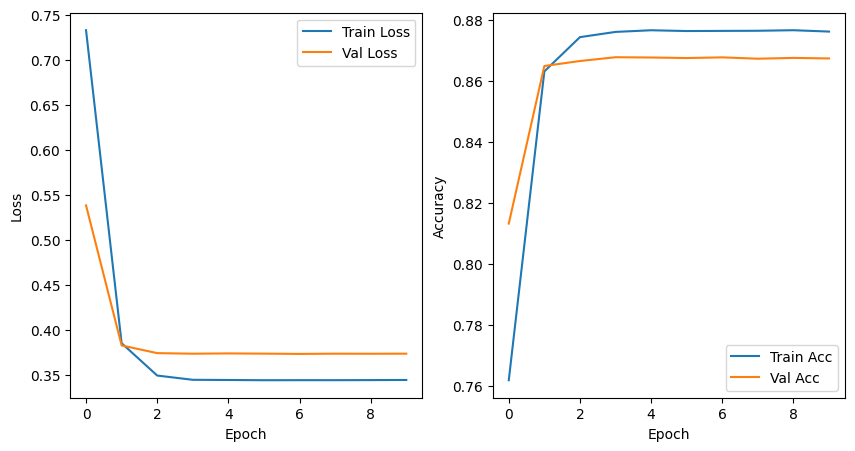

In [ ]:
# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss() # set criterion as crossEntropyLoss
optimizer = optim.Adam(cnn.parameters(), lr=0.005)
# for using Exponential learning rate scheduler uncomment the Exponential statement and comment the StepLr statement
scheduler = StepLR(optimizer, step_size=1, gamma=0.1)
# scheduler = ExponentialLR(optimizer, gamma=0.1)

# Train the CNN model
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
cnn.to(device)

num_epochs = 10  # Number of epochs for training
train_losses = []  # List to store training losses
val_losses = []  # List to store validation losses
train_acc = []  # List to store training accuracy
val_acc = []  # List to store validation accuracy

start_time = time.time()  # Start time for training

# Training loop over specified number of epochs
for epoch in range(num_epochs):
    # Training
    cnn.train()  # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0
    for i, (inputs, labels) in enumerate(train_dl):
        inputs, labels = inputs.to(device), labels.to(device)  # Move data to the appropriate device
        optimizer.zero_grad()  # Clear gradients
        outputs = cnn(inputs)  # Forward pass
        loss = criterion(outputs, labels)  # Calculate loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights

        # Update training statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    # Calculate and record training loss and accuracy
    epoch_loss_t = running_loss / len(train_dl)
    epoch_acc_t = correct / total
    train_losses.append(epoch_loss_t)
    train_acc.append(epoch_acc_t)

    # Validation
    cnn.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():  # Disable gradient computation
        for i, (inputs, labels) in enumerate(validation_dl):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = cnn(inputs)
            loss = criterion(outputs, labels)

            # Update validation statistics
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    # Calculate and record validation loss and accuracy
    epoch_loss_v = running_loss / len(validation_dl)
    epoch_acc_v = correct / total
    val_losses.append(epoch_loss_v)
    val_acc.append(epoch_acc_v)

    # Update learning rate
    scheduler.step()

    # Print the training and validation loss and accuracy for each epoch
    print('Epoch [{}/{}], Train Loss: {:.3f}, Train Acc: {:.3f}, Val Loss: {:.3f}, Val Acc: {:.3f}'
          .format(epoch + 1, num_epochs, train_losses[-1], train_acc[-1], val_losses[-1], val_acc[-1]))

end_time = time.time()  # End time for training
print(f"Training time: {end_time - start_time:.2f} seconds")


# Plot the training and validation loss and accuracy
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Evaluate Model Function

###The `evaluate_model` function is designed to evaluate a trained PyTorch model on a given dataset. It computes the confusion matrix and classification report, providing insights into the model's performance.
#### Parameters:
####- `model`: The trained PyTorch model to evaluate.
####- `data_loader`: DataLoader for the dataset.
####- `device`: Device to perform computations (e.g., 'cuda' for GPU or 'cpu').
##### Returns:
####- A tuple containing the confusion matrix and classification report.
####  Steps:
#####1. **Set Model to Evaluation Mode**: The function sets the model to evaluation mode using `model.eval()`.
#####2. **Evaluate on Dataset**: It iterates over the dataset, computes predictions, and collects true labels and predictions.
#####3. **Compute Confusion Matrix**: Using the collected labels and predictions, it computes the confusion matrix.
#####4. **Calculate Classification Report**: It generates the classification report, including metrics such as precision, recall, and F1-score.
#####5. **Print and Visualize Results**: The classification report is printed, and a heatmap of the confusion matrix is visualized using Matplotlib and Seaborn.
#####6. **Return Results**: Finally, the function returns the confusion matrix and classification report for further analysis.

##This function is useful for assessing the performance of a model across different classes and identifying areas for improvement.


In [ ]:
def evaluate_model(model, data_loader, device):
    """
    Evaluate a trained model's performance on a dataset using a DataLoader.

    This function sets the model to evaluation mode, iterates over the dataset to
    collect predictions, calculates a confusion matrix, and generates a classification
    report for further analysis of the model's performance.

    Parameters:
        model (torch.nn.Module): The trained model to be evaluated.
        data_loader (torch.utils.data.DataLoader): DataLoader providing the dataset for evaluation.
        device (torch.device): The device (CPU or GPU) on which to perform computations.

    Returns:
        Tuple[np.ndarray, str]: A tuple containing the confusion matrix and the
        classification report as its two elements.

    Outputs:
        The function plots the confusion matrix and prints the classification report.
    """
    # Set the model to evaluation mode
    model.eval()
    # Initialize lists to store predictions and actual labels
    all_labels = []
    all_preds = []

    # Process each batch in the DataLoader
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute the confusion matrix and classification report
    cm = confusion_matrix(all_labels, all_preds)
    # Calculate the classification report
    cr = classification_report(all_labels, all_preds, target_names=[f'Class {i}' for i in range(47)], output_dict=False)

    # Print the classification report
    print("Classification Report:")
    print(cr)

    # Plotting the confusion matrix
    plt.figure(figsize=(16, 9))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[f'Class {i}' for i in range(47)], yticklabels=[f'Class {i}' for i in range(47)])
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

    return cm, cr  # Return the confusion matrix and classification report


## The code below is used to call the evalute modle with the test datasets.

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.62      0.79      0.69       400
     Class 1       0.52      0.80      0.63       400
     Class 2       0.91      0.86      0.89       400
     Class 3       0.96      0.97      0.96       400
     Class 4       0.93      0.89      0.91       400
     Class 5       0.90      0.85      0.88       400
     Class 6       0.91      0.92      0.92       400
     Class 7       0.95      0.95      0.95       400
     Class 8       0.89      0.91      0.90       400
     Class 9       0.63      0.88      0.73       400
    Class 10       0.93      0.96      0.94       400
    Class 11       0.91      0.93      0.92       400
    Class 12       0.94      0.95      0.95       400
    Class 13       0.88      0.92      0.90       400
    Class 14       0.96      0.96      0.96       400
    Class 15       0.72      0.55      0.62       400
    Class 16       0.93      0.93      0.93       400
    

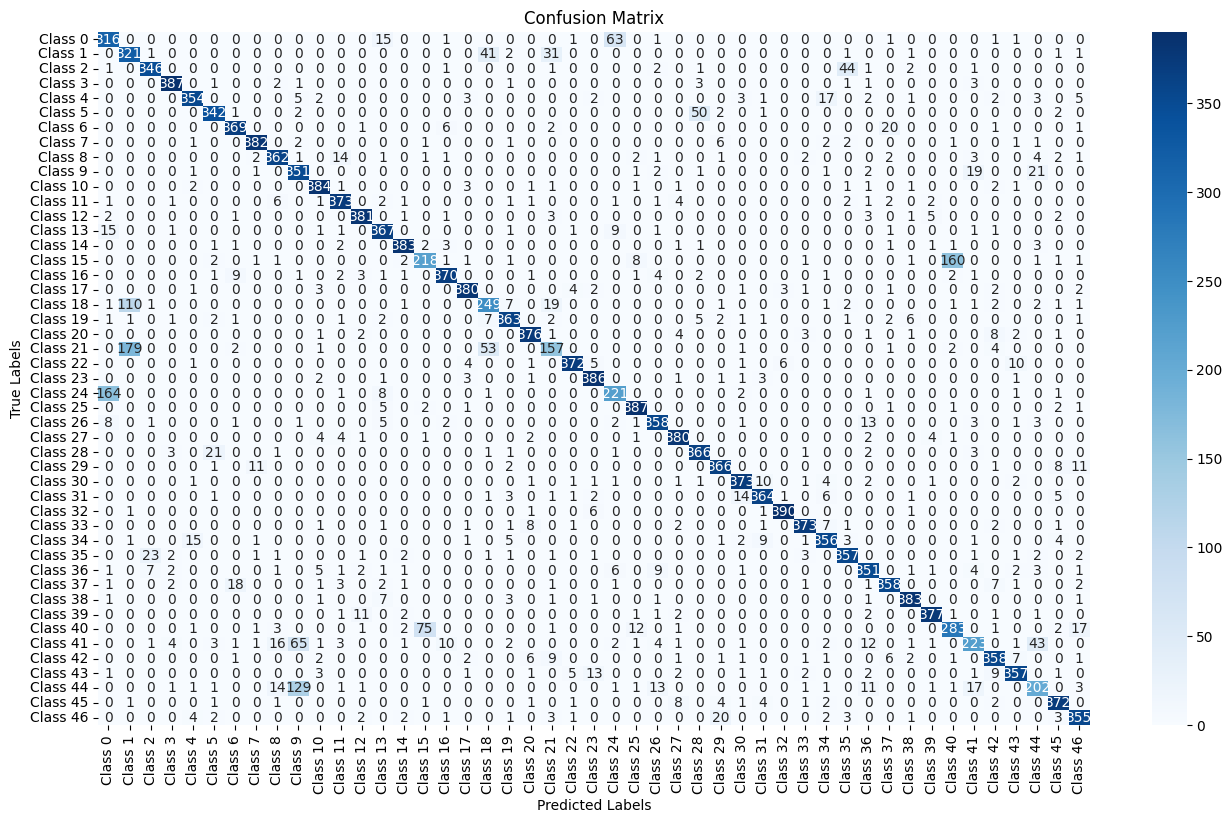

In [ ]:
# Now you can call this function with the test DataLoader
test_cm, test_cr = evaluate_model(mlp, test_dl, device)

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.64      0.75      0.69       400
     Class 1       0.54      0.70      0.61       400
     Class 2       0.90      0.85      0.87       400
     Class 3       0.98      0.97      0.98       400
     Class 4       0.88      0.90      0.89       400
     Class 5       0.91      0.85      0.88       400
     Class 6       0.92      0.92      0.92       400
     Class 7       0.95      0.97      0.96       400
     Class 8       0.89      0.92      0.90       400
     Class 9       0.65      0.83      0.73       400
    Class 10       0.93      0.94      0.94       400
    Class 11       0.94      0.94      0.94       400
    Class 12       0.93      0.94      0.94       400
    Class 13       0.90      0.89      0.90       400
    Class 14       0.96      0.96      0.96       400
    Class 15       0.67      0.52      0.58       400
    Class 16       0.93      0.91      0.92       400
    

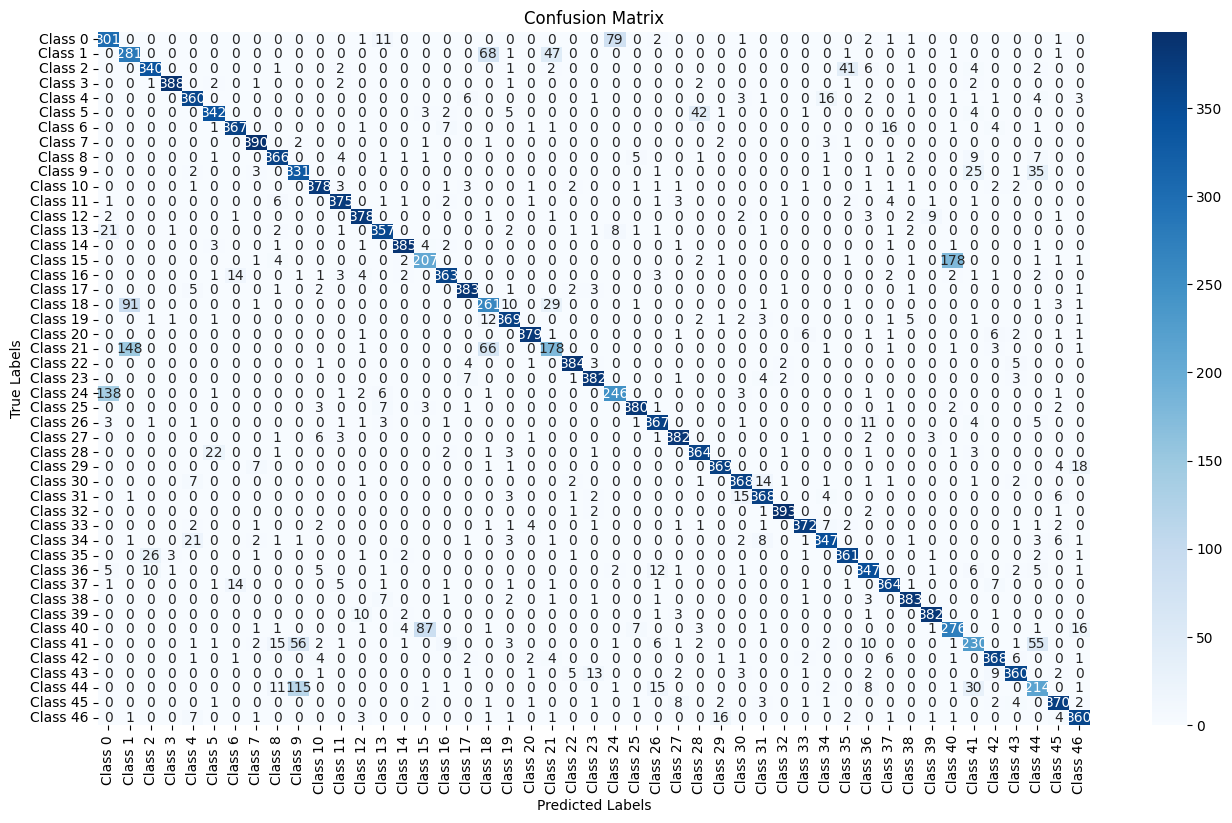

In [ ]:
# Now you can call this function with your test DataLoader
test_cm, test_cr = evaluate_model(cnn, test_dl, device)

#Once we have evaluated the model, now we can save the model as its weights and use the model or export the model, typical steps involve:
###1. Save the model
###2. Load the model
###3. Move to gpu is used
###4. Optionally we can create a test function and load the model.

In [ ]:
# # Save the model's state dictionary
# torch.save(cnn.state_dict(), 'cnn_model.pth')

# # First, initialize the model
# cnn_loaded = CNN(batch_norm=True, dropout=False, activation='relu', l1_regularization=False, l2_regularization=True)

# # Now, load the weights
# cnn_loaded.load_state_dict(torch.load('cnn_model.pth'))

# # set the model to eval mode if you are in inference mode
# cnn_loaded.eval()

# # If using a GPU, move the model to GPU
# cnn_loaded.to(device)


In [ ]:
def test_fun(model, test_dl, device, criterion, classes, mapping):
    """
    Evaluate the performance of a neural network model on test data using PyTorch.

    This function sets the model to evaluation mode, iterates over the test dataset to compute the loss
    and accuracy, collects predictions, and visualizes a subset of predictions. It also provides
    HTML-formatted output in a Jupyter notebook to enhance visual understanding of the process.

    Parameters:
        model (torch.nn.Module): The trained neural network model to be evaluated.
        test_dl (torch.utils.data.DataLoader): DataLoader for the test dataset, providing batches of data.
        device (torch.device): The device (CPU or GPU) on which computations will be performed.
        criterion (torch.nn.Module): The loss function used for evaluating model performance.
        classes (List[str]): List of class names corresponding to label indices.
        mapping (Dict[int, str]): Dictionary mapping label indices to their corresponding class names.

    Effects:
        This function does not return any values but performs the following actions:
        - Sets the model to evaluation mode.
        - Iterates over the test dataset, computes predictions, updates running loss, and counts correct predictions.
        - Outputs visual and textual information to the notebook's display, aiding in performance evaluation.
        - Calls external functions to plot and summarize results.

    Returns:
        None. Results are visualized and printed directly within the function through external calls.
    """
    # Set the model to evaluation mode to disable dropout and batch normalization effects
    model.eval()  # if model is loaded externally then use this code---> cnn_loaded.eval()
    # Initialize running loss and correct predictions counter
    running_loss = 0.0
    correct = 0
    predicted_labels = []
    true_labels = []
    total = 0
    # Display start of testing phase in notebook
    display(HTML(f"<div style='font-size:20px;'>Watch {type(model).__name__} conquer the test data like a boss!</div>"))

    # Process each batch in the test DataLoader
    with torch.no_grad():
        for i, (inputs, labels) in zip(range(6), test_dl):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Update running loss and prediction accuracy
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Collect predictions and true labels for later analysis
            predicted_labels.extend(predicted.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

        # Visualize top six predictions from the last processed batch
        indices = torch.randperm(len(inputs))[:6]

        # Change the display message to reflect six images and call the updated function
        display(HTML(f"<div style='font-size:20px;'>Visualizing the top six swag predictions:</div>"))
        plot_top_six(inputs[indices], predicted[indices], labels[indices], mapping, device)  # Show 6 images


    # Summarize and display overall performance
    summarize_performance(running_loss, correct, total, predicted_labels, true_labels, classes)

def plot_top_six(inputs, predicted, true, mapping, device):
    """
    Display a grid of six images from the test set along with their predicted and true labels.

    This function visualizes six images, facilitating the comparison of the model's predictions
    against the actual labels. It creates a 2x3 grid of images, each annotated with its corresponding
    predicted and true label names. The function is designed to aid in the qualitative assessment
    of a model's performance by visually displaying a subset of results.

    Parameters:
        inputs (torch.Tensor): A batch of images from which six will be displayed.
        predicted (torch.Tensor): The predicted labels for the images in the `inputs` tensor.
        true (torch.Tensor): The true labels for the images in the `inputs` tensor.
        mapping (Dict[int, str]): A dictionary mapping label indices to their respective names.
        device (torch.device): The device (CPU or GPU) the data is located on. This parameter is
                               primarily used for ensuring compatibility and may not be directly utilized.

    Returns:
        None. This function renders a figure and does not return any value.
    """
    num_images = 6  # Set the number of images to display to six
    num_columns = 3   # Images per row, adjusted for six images
    num_rows = 2  # Adjusted for six images

    # Adjust the figure size as needed for six images
    figure = plt.figure(figsize=(2 * num_columns, 2 * num_rows))

    # Iterate over each image and plot it with the corresponding labels
    for j in range(num_images):
        ax = figure.add_subplot(num_rows, num_columns, j+1)
        img = inputs[j].cpu().squeeze()  # Ensure image is moved to CPU and squeezed
        ax.imshow(img, cmap="gray")  # Use grayscale color map for better visibility
        ax.title.set_text(f"P: {mapping[predicted[j].item()]}\nT: {mapping[true[j].item()]}")  # Set title with predicted and true labels
        plt.axis("off")  # Hide axes for better visuals

    plt.show()  # Display the plot

def summarize_performance(running_loss, correct, total, predicted_labels, true_labels, classes):
    """
    Summarize and display the performance of the model after testing.

    This function calculates the overall loss and accuracy from the test data,
    displays them using HTML in a Jupyter notebook, and visualizes the confusion
    matrix to assess the model's predictive performance across different classes.
    Additionally, it generates a detailed classification report.

    Parameters:
        running_loss (float): The accumulated loss over all test batches.
        correct (int): Number of correctly predicted labels.
        total (int): Total number of data points evaluated.
        predicted_labels (List[int]): List of labels predicted by the model.
        true_labels (List[int]): List of actual labels from the test data.
        classes (List[str]): List of class names corresponding to label indices.

    Returns:
        None. This function renders visual outputs directly and prints the classification
        report in the console.
    """
    # Calculate test loss and accuracy
    test_loss = running_loss / total
    test_acc = 100 * correct / total

    # Display loss and accuracy in an HTML formatted text
    display(HTML(f"<div style='font-size:20px;'>Loss Meter: {test_loss:.3f}</div>"))
    display(HTML(f"<div style='font-size:20px;'>Accuracy Tracker: {test_acc:.2f}% - Nailed it? Yes/No/Yes!!</div>"))

    # The classic confusion matrix, where confusion is actually a good thing (sometimes).
    cm = confusion_matrix(true_labels, predicted_labels, labels=list(range(len(classes))))
    plt.figure(figsize=(10, 10))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt='d', xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title('Confusion Matrix of Truths')
    plt.show()

    # Display a message for performance report generation
    display(HTML(f"<div style='font-size:20px;'>Generating the performance report...</div>"))
    # Generate and print the classification report
    report = classification_report(true_labels, predicted_labels, target_names=classes, digits=3)
    print(report)

# The code below creates a dictionary with key of class for which values are ASCII.

In [ ]:
# Create a dictionary from the series where keys are the class indices and values are ASCII values
mapping_dict = mapping.to_dict()

# Convert ASCII values to characters for better readability
mapping_dict = {k: chr(v) for k, v in mapping_dict.items()}

# Prepare a list of classes from the mapping
classes = [chr(value) for value in mapping.values]

print(f'Classes: {classes}\n')
print(f'Map for Classes: {mapping_dict}\n')

Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']

Map for Classes: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: 'A', 11: 'B', 12: 'C', 13: 'D', 14: 'E', 15: 'F', 16: 'G', 17: 'H', 18: 'I', 19: 'J', 20: 'K', 21: 'L', 22: 'M', 23: 'N', 24: 'O', 25: 'P', 26: 'Q', 27: 'R', 28: 'S', 29: 'T', 30: 'U', 31: 'V', 32: 'W', 33: 'X', 34: 'Y', 35: 'Z', 36: 'a', 37: 'b', 38: 'd', 39: 'e', 40: 'f', 41: 'g', 42: 'h', 43: 'n', 44: 'q', 45: 'r', 46: 't'}



## The cell below uses a test function which was created to test the model againt the test dataset along with classification report, it takes the following parameters:
### 1. `model`: The model we want to test the dataset against(here we are using mlp model)
### 2. `device`: for computational purpose, cpu if not gpu.
### 3. `criterion`: takes loss
### 4. `classes`: number of classes as list
### 5. `mapping`: mapping dictionary

##Therefore, we intend to test and plot top six test dataset, accuracy of the model, confusion matrix and performance report.

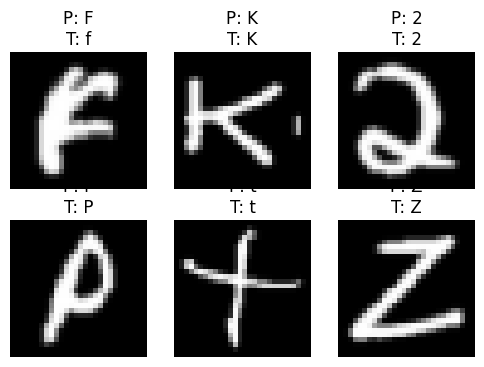

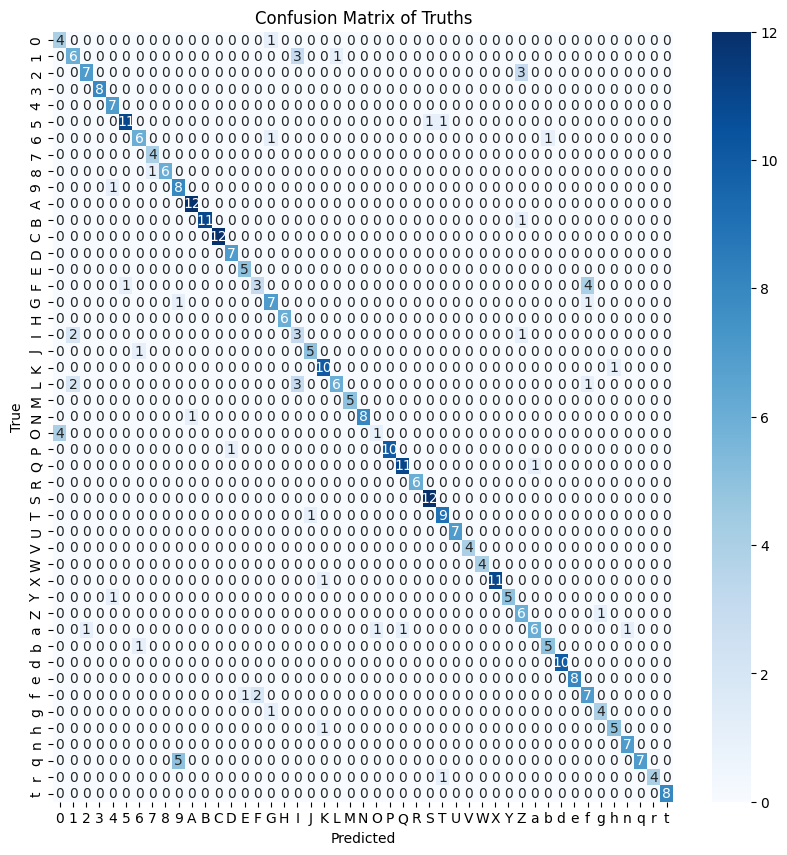

              precision    recall  f1-score   support

           0      0.500     0.800     0.615         5
           1      0.600     0.600     0.600        10
           2      0.875     0.700     0.778        10
           3      1.000     1.000     1.000         8
           4      0.778     1.000     0.875         7
           5      0.917     0.846     0.880        13
           6      0.750     0.750     0.750         8
           7      0.800     1.000     0.889         4
           8      1.000     0.857     0.923         7
           9      0.571     0.889     0.696         9
           A      0.923     1.000     0.960        12
           B      1.000     0.917     0.957        12
           C      1.000     1.000     1.000        12
           D      0.875     1.000     0.933         7
           E      0.833     1.000     0.909         5
           F      0.600     0.375     0.462         8
           G      0.700     0.778     0.737         9
           H      1.000    

In [ ]:
test_fun(model=mlp, test_dl=test_dl, device=device, criterion=criterion, classes=classes, mapping=mapping_dict)


## The cell below uses a test function which was created to test the model againt the test dataset along with classification report, it takes the following parameters:
### 1. `model`: The model we want to test the dataset against(here we are using cnn model)
### 2. `device`: for computational purpose, cpu if not gpu.
### 3. `criterion`: takes loss
### 4. `classes`: number of classes as list
### 5. `mapping`: mapping dictionary
##Therefore, we intend to test and plot top six test dataset, accuracy of the model, confusion matrix and performance report.

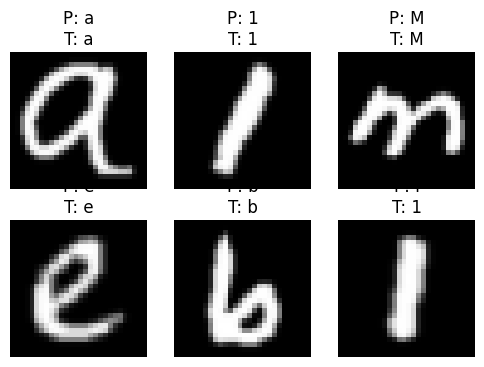

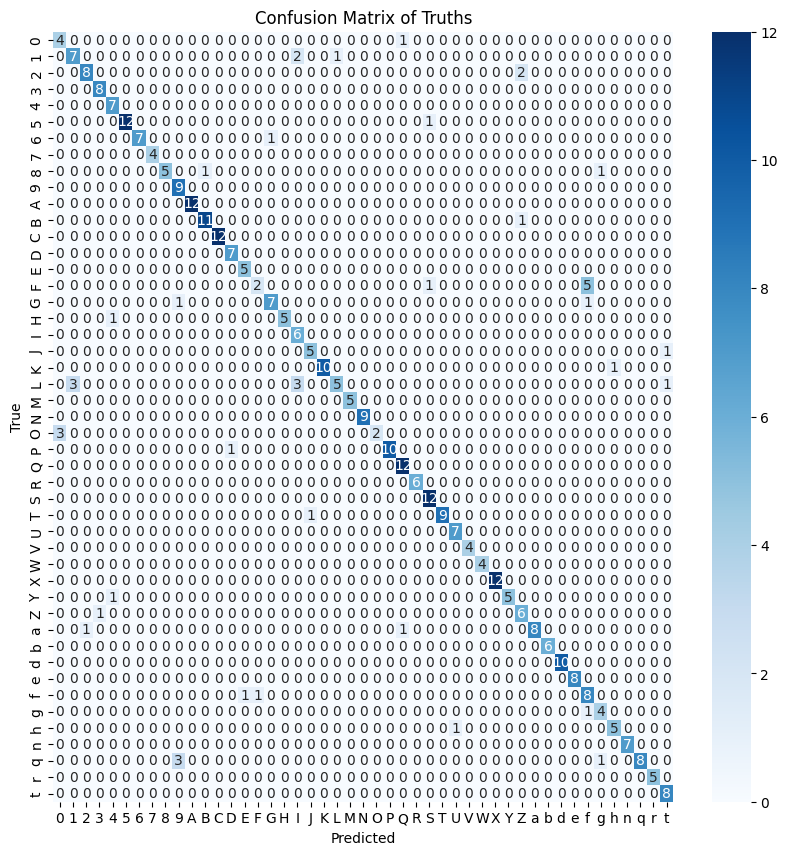

              precision    recall  f1-score   support

           0      0.571     0.800     0.667         5
           1      0.700     0.700     0.700        10
           2      0.889     0.800     0.842        10
           3      0.889     1.000     0.941         8
           4      0.778     1.000     0.875         7
           5      1.000     0.923     0.960        13
           6      1.000     0.875     0.933         8
           7      1.000     1.000     1.000         4
           8      1.000     0.714     0.833         7
           9      0.692     1.000     0.818         9
           A      1.000     1.000     1.000        12
           B      0.917     0.917     0.917        12
           C      1.000     1.000     1.000        12
           D      0.875     1.000     0.933         7
           E      0.833     1.000     0.909         5
           F      0.667     0.250     0.364         8
           G      0.875     0.778     0.824         9
           H      1.000    

In [ ]:
test_fun(model=cnn, test_dl=test_dl, device=device, criterion=criterion, classes=classes, mapping=mapping_dict)
